# Rest-Frame Properties, Diagnostics, and Batch Processing

tengri computes derived galaxy properties — M★, SFR, sSFR, D4000, UV slope
— as differentiable functions of the model parameters. This notebook shows
how to extract and batch-process them.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, plot_sfh, setup_style  # noqa: E402

setup_style()

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)

spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model = Model(spec, ssp_data, filters=filters)
model.precompute_spectroscopy(WAVE_OBS)

W0321 13:56:08.901537 14726288 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_9659/2214782616.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_9659/2214782616.py:21: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model.precompute_spectroscopy(WAVE_OBS)


In [3]:
# Fit a single galaxy
key = jax.random.PRNGKey(42)
true_params = spec.sample(key)
# Override tsnorm to a typical star-forming galaxy (still forming stars now)
true_params = {**true_params}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(-0.5)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=30.0, key=key)

fitter = Fitter(model, mock.flux_obs, mock.noise, data_type="spectroscopy")
_ = fitter.run("map", n_steps=500, verbose=False)
result = fitter.run(
    "native_geovi", n_iterations=15, n_samples=6, n_seeds=3,
    n_posterior_samples=2000, verbose=False,
)
print(f"Fit: {result.wall_time_s:.1f}s, {len(list(result.samples.values())[0])} samples")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0321 13:56:12.162560 14726185 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:56:13.498999 14726185 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:56:25.009807 14726185 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0321 13:56:34.862821 14726185 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Fit: 47.2s, 2000 samples


In [4]:
# Derived quantities from posterior
sfh_derived = []
for i in range(min(500, len(list(result.samples.values())[0]))):
    p = {k: v[i] for k, v in result.samples.items()}
    sfh_i = model.predict_sfh(p)
    sfr = np.array(sfh_i["sfr_mean"])
    t = np.array(sfh_i["t_gyr"])
    # Compute stellar mass (integral of SFR)
    dt = np.diff(t * 1e9)
    m_star = np.sum(sfr[:-1] * np.abs(dt))
    # SFR at 100 Myr
    idx_100 = np.argmin(np.abs(t - 0.1))
    sfr_100 = sfr[idx_100]
    sfh_derived.append({"m_star": m_star, "sfr_100": sfr_100, "ssfr": sfr_100 / max(m_star, 1e-10)})

m_star_arr = np.array([d["m_star"] for d in sfh_derived])
sfr_100_arr = np.array([d["sfr_100"] for d in sfh_derived])
ssfr_arr = np.array([d["ssfr"] for d in sfh_derived])

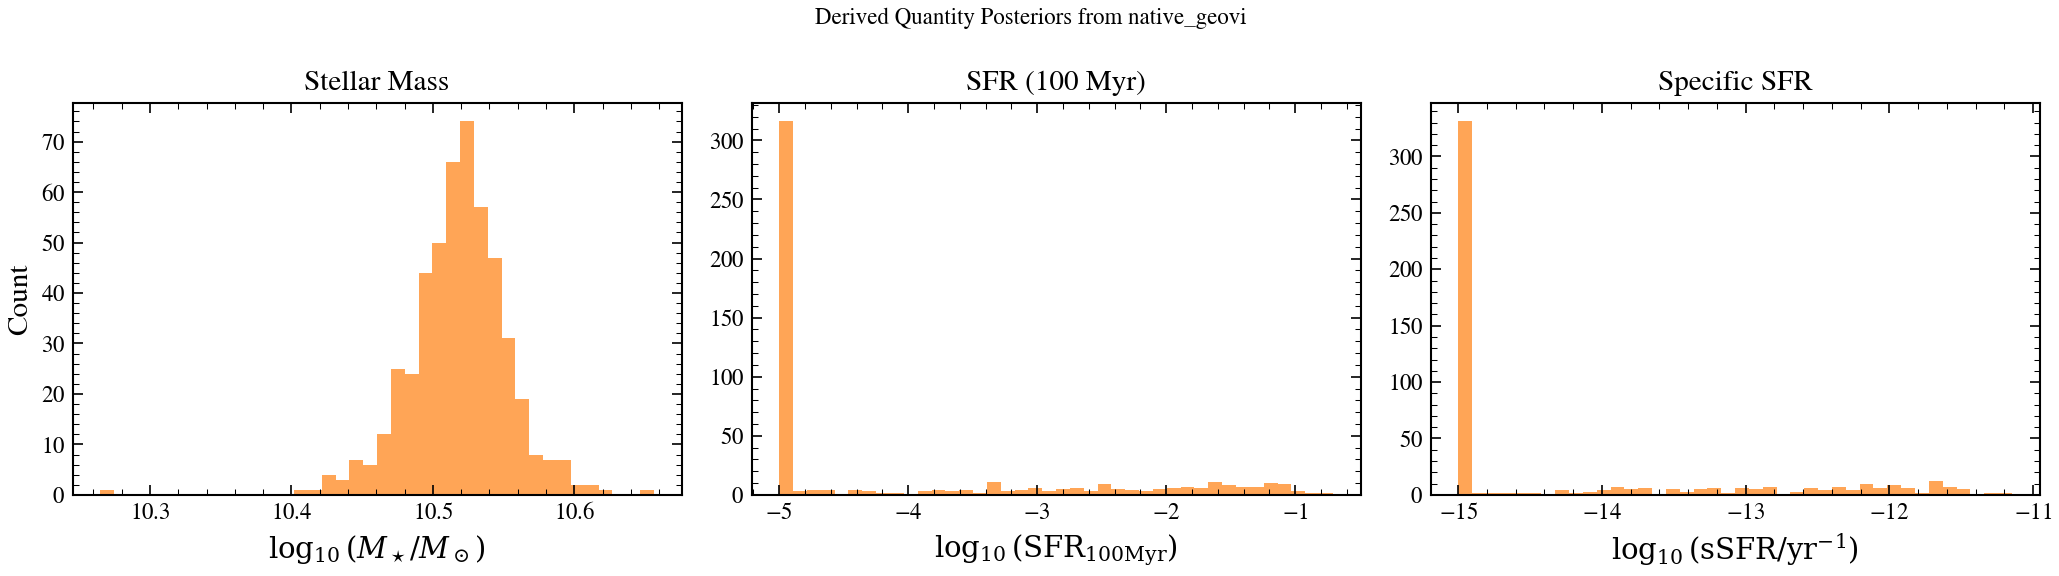

In [5]:
# --- FIGURE 1: Derived quantity posteriors (histograms) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

ax1.hist(np.log10(np.clip(m_star_arr, 1, None)), bins=40, color=COLORS["geovi"], alpha=0.7)
ax1.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax1.set_ylabel("Count")
ax1.set_title("Stellar Mass")

ax2.hist(np.log10(np.clip(sfr_100_arr, 1e-5, None)), bins=40, color=COLORS["geovi"], alpha=0.7)
ax2.set_xlabel(r"$\log_{10}({\rm SFR}_{100\rm Myr})$")
ax2.set_title("SFR (100 Myr)")

ax3.hist(np.log10(np.clip(ssfr_arr, 1e-15, None)), bins=40, color=COLORS["geovi"], alpha=0.7)
ax3.set_xlabel(r"$\log_{10}({\rm sSFR} / {\rm yr}^{-1})$")
ax3.set_title("Specific SFR")

fig.suptitle("Derived Quantity Posteriors from native_geovi", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_derived_posteriors.png"), dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Batch: 100 galaxies from prior, compute derived
N_BATCH = 100
batch_keys = jax.random.split(jax.random.PRNGKey(0), N_BATCH)
batch_params = jax.vmap(spec.sample)(batch_keys)

batch_sfh = []
t0 = time.perf_counter()
for i in range(N_BATCH):
    p = {k: v[i] for k, v in batch_params.items()}
    sfh_i = model.predict_sfh(p)
    batch_sfh.append(sfh_i)
t_batch = time.perf_counter() - t0
print(f"SFH for {N_BATCH} galaxies: {t_batch:.2f}s ({t_batch/N_BATCH*1e3:.1f} ms/galaxy)")

SFH for 100 galaxies: 0.14s (1.4 ms/galaxy)


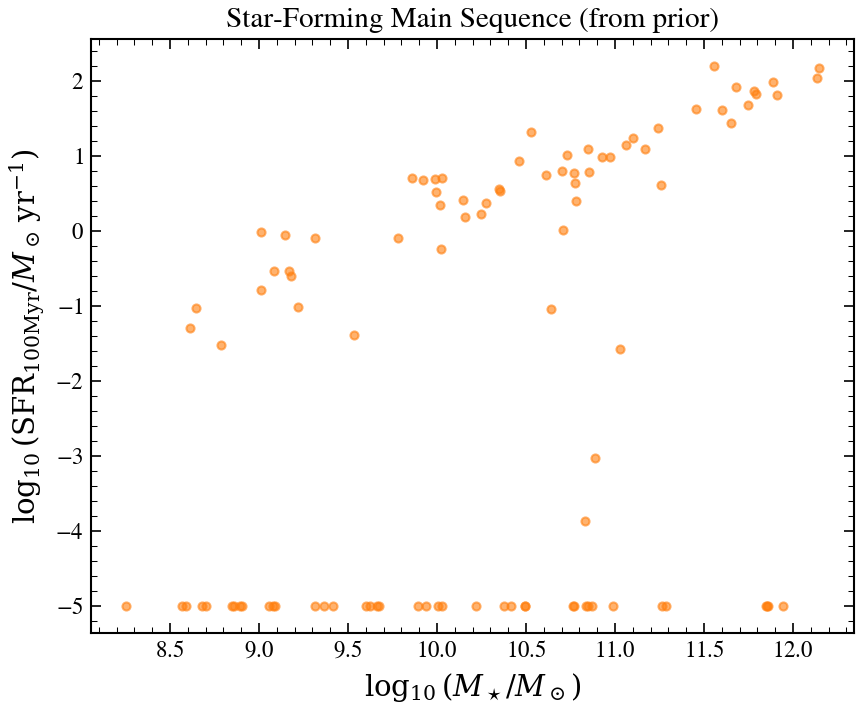

In [7]:
# --- FIGURE 3: M★ vs SFR (main sequence from prior) ---
batch_mstar = []
batch_sfr = []
for sfh_i in batch_sfh:
    sfr = np.array(sfh_i["sfr_mean"])
    t = np.array(sfh_i["t_gyr"])
    dt = np.diff(t * 1e9)
    ms = np.sum(sfr[:-1] * np.abs(dt))
    idx_100 = np.argmin(np.abs(t - 0.1))
    batch_mstar.append(ms)
    batch_sfr.append(sfr[idx_100])

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np.log10(np.clip(batch_mstar, 1, None)),
           np.log10(np.clip(batch_sfr, 1e-5, None)),
           s=15, alpha=0.6, color=COLORS["geovi"])
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax.set_ylabel(r"$\log_{10}({\rm SFR}_{100\rm Myr} / M_\odot\,{\rm yr}^{-1})$")
ax.set_title("Star-Forming Main Sequence (from prior)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_main_sequence.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Scaling test
for n in [10, 50, 100, 500]:
    keys_n = jax.random.split(jax.random.PRNGKey(0), n)
    params_n = jax.vmap(spec.sample)(keys_n)
    batch_phot = jax.jit(jax.vmap(model.predict_photometry))
    _ = batch_phot(params_n)
    _.block_until_ready()
    t0 = time.perf_counter()
    for _ in range(20):
        r = batch_phot(params_n)
        r.block_until_ready()
    t = (time.perf_counter() - t0) / 20 * 1e3
    print(f"  vmap({n:>4d}): {t:.1f} ms  ({t/n*1e3:.1f} µs/galaxy)")

  vmap(  10): 0.1 ms  (13.1 µs/galaxy)


  vmap(  50): 0.3 ms  (5.4 µs/galaxy)
  vmap( 100): 0.4 ms  (4.0 µs/galaxy)


  vmap( 500): 1.0 ms  (2.0 µs/galaxy)


## Summary

- Derived quantities (M★, SFR, sSFR) computed from the same posterior samples.
- Batch processing via vmap: sublinear scaling from XLA parallelism.
- All quantities are differentiable — can be used in gradient-based objectives.